# Notebook 02 — FakeQuantize Unit Tests

Verify affine INT8 quantization math against `torch.quantize_per_tensor`
**to test:**
1. Scale / zero-point formula matches PyTorch's convention
2. Quantize → dequantize round-trip error is near floating-point precision
3. Clamp behaviour at the tails (values outside calibration range)
4. Weight quantization (symmetric) vs activation quantization (asymmetric)
5. That gradients flow through the straight-through estimator (STE)
6. A realistic conv-weight tensor and a realistic activation tensor, end-to-end

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
print(f"PyTorch {torch.__version__}")

PyTorch 2.11.0


---
## 1  Affine quantization math

The affine (asymmetric) INT8 mapping used by PyTorch's `quint8` dtype:

$$
\text{scale} = \frac{x_{\max} - x_{\min}}{255}, \quad
\text{zero\_point} = \text{round}\!\left(-\frac{x_{\min}}{\text{scale}}\right) \text{ clipped to } [0, 255]
$$

$$
q = \text{clamp}\!\left(\text{round}\!\left(\frac{x}{\text{scale}}\right) + \text{zero\_point},\; 0,\; 255\right)
$$

$$
\hat{x} = (q - \text{zero\_point}) \times \text{scale}
$$

In [2]:
def compute_scale_zp(x_min: float, x_max: float, n_bits: int = 8):
    """Asymmetric affine scale/zero-point from observed [x_min, x_max]."""
    q_min, q_max = 0, 2**n_bits - 1          # quint8: [0, 255]
    scale = (x_max - x_min) / (q_max - q_min)
    zero_point = int(round(-x_min / scale))
    zero_point = int(np.clip(zero_point, q_min, q_max))
    return scale, zero_point


def fake_quantize(x: torch.Tensor, scale: float, zero_point: int, n_bits: int = 8):
    """Quantize then immediately dequantize (no integer storage)."""
    q_min, q_max = 0, 2**n_bits - 1
    q = torch.clamp(torch.round(x / scale) + zero_point, q_min, q_max)
    x_hat = (q - zero_point) * scale
    return x_hat


print("helpers defined")

helpers defined


---
## 2  Scale / zero-point: match PyTorch exactly

In [ ]:
# Synthetic tensor with a non-zero minimum (tests the asymmetric path)
x = torch.tensor([-1.5, -0.8, 0.0, 0.4, 1.2, 2.7])

x_min, x_max = float(x.min()), float(x.max())
our_scale, our_zp = compute_scale_zp(x_min, x_max)

q_torch = torch.quantize_per_tensor(x, scale=our_scale, zero_point=our_zp, dtype=torch.quint8)
torch_scale = q_torch.q_scale()
torch_zp    = q_torch.q_zero_point()

print(f"Our   scale={our_scale:.6f}  zero_point={our_zp}")
print(f"Torch scale={torch_scale:.6f}  zero_point={torch_zp}")

assert abs(our_scale - torch_scale) < 1e-6, "scale mismatch!"
assert our_zp == torch_zp, "zero_point mismatch!"
print("\n✓  scale and zero_point match PyTorch")

Our   scale=0.016471  zero_point=91
Torch scale=0.016471  zero_point=91

✓  scale and zero_point match PyTorch


---
## 3  Round-trip error: must be ≤ scale/2 everywhere

In [4]:
x = torch.randn(1000) * 2.0          # realistic activation range
x_min, x_max = float(x.min()), float(x.max())
scale, zp = compute_scale_zp(x_min, x_max)

# Our fake-quant
x_hat_ours = fake_quantize(x, scale, zp)

# PyTorch's fake-quant (dequantize after quantize_per_tensor)
x_hat_torch = torch.dequantize(
    torch.quantize_per_tensor(x, scale=scale, zero_point=zp, dtype=torch.quint8)
)

err_ours  = (x - x_hat_ours).abs()
err_torch = (x - x_hat_torch).abs()
cross_err = (x_hat_ours - x_hat_torch).abs()

print(f"Max round-trip error (ours):   {err_ours.max().item():.2e}  (bound: {scale/2:.2e})")
print(f"Max round-trip error (torch):  {err_torch.max().item():.2e}")
print(f"Max cross error (ours vs torch): {cross_err.max().item():.2e}")

assert err_ours.max().item()  <= scale / 2 + 1e-6, "round-trip error exceeds scale/2!"
assert cross_err.max().item() <  1e-5,             "our output diverges from PyTorch!"
print("\n✓  round-trip error within tolerance, matches PyTorch")

Max round-trip error (ours):   2.40e-02  (bound: 2.40e-02)
Max round-trip error (torch):  2.40e-02
Max cross error (ours vs torch): 0.00e+00

✓  round-trip error within tolerance, matches PyTorch


---
## 4  Tail clamp: out-of-range values saturate, not wrap

In [5]:
# Calibrate on a narrow range, then feed values outside it
x_calib = torch.linspace(-1.0, 1.0, 200)
scale, zp = compute_scale_zp(-1.0, 1.0)

x_test = torch.tensor([-5.0, -1.0, 0.0, 1.0, 5.0])
x_hat  = fake_quantize(x_test, scale, zp)

print("Input  → FakeQuant output")
for xi, xo in zip(x_test.tolist(), x_hat.tolist()):
    print(f"  {xi:+.1f}  →  {xo:+.4f}")

# Values beyond calibration range should saturate at the calibration boundary
assert x_hat[0].item() >= -1.0 - scale, "underflow not clamped!"
assert x_hat[-1].item() <= 1.0 + scale,  "overflow not clamped!"
print("\n✓  out-of-range values saturate correctly")

Input  → FakeQuant output
  -5.0  →  -1.0039
  -1.0  →  -0.9961
  +0.0  →  +0.0000
  +1.0  →  +0.9961
  +5.0  →  +0.9961

✓  out-of-range values saturate correctly


---
## 5  Symmetric (weight) vs asymmetric (activation) quantization

Weights are typically symmetric around zero → `zero_point = 0`.  
We can check that our formula degenerates correctly when `x_min = -x_max`.

In [6]:
# Weight tensor: roughly zero-mean (post BN-fold situation)
w = torch.randn(64, 3, 3, 3) * 0.05     # typical conv weight scale
w_min, w_max = float(w.min()), float(w.max())

# Asymmetric path (what our FakeQuantize will use for both weights and activations)
scale_asym, zp_asym = compute_scale_zp(w_min, w_max)

# Symmetric path: force min = -max
abs_max = max(abs(w_min), abs(w_max))
scale_sym, zp_sym = compute_scale_zp(-abs_max, abs_max)

print(f"Asymmetric: scale={scale_asym:.6f}  zp={zp_asym}")
print(f"Symmetric:  scale={scale_sym:.6f}   zp={zp_sym}  (expect zp≈127)")

w_hat_asym = fake_quantize(w, scale_asym, zp_asym)
w_hat_sym  = fake_quantize(w, scale_sym,  zp_sym)

print(f"\nMean abs error — asymmetric: {(w - w_hat_asym).abs().mean():.2e}")
print(f"Mean abs error — symmetric:  {(w - w_hat_sym).abs().mean():.2e}")
print("(Symmetric wastes ~1 bit on the zero-crossing but is hardware-friendlier)")
print("\n✓  both paths produce bounded error")

Asymmetric: scale=0.001224  zp=125
Symmetric:  scale=0.001251   zp=128  (expect zp≈127)

Mean abs error — asymmetric: 2.99e-04
Mean abs error — symmetric:  3.11e-04
(Symmetric wastes ~1 bit on the zero-crossing but is hardware-friendlier)

✓  both paths produce bounded error


---
## 6  Straight-through estimator (STE): gradients flow through round()

During PTQ we don't train, but the model still needs `requires_grad=True` buffers to work with PyTorch's autograd (e.g. if you ever call `.backward()` for debugging). The STE trick is to use `x + (round(x) - x).detach()` so the backward pass sees an identity.

In [7]:
def fake_quantize_ste(x: torch.Tensor, scale: float, zero_point: int, n_bits: int = 8):
    """Same as fake_quantize but gradient-safe via STE."""
    q_min, q_max = 0, 2**n_bits - 1
    x_scaled = x / scale
    # STE: forward uses round, backward treats it as identity
    x_rounded = x_scaled + (torch.round(x_scaled) - x_scaled).detach()
    q = torch.clamp(x_rounded + zero_point, q_min, q_max)
    x_hat = (q - zero_point) * scale
    return x_hat


x = torch.randn(8, requires_grad=True)
scale, zp = compute_scale_zp(float(x.min().item()), float(x.max().item()))

x_hat = fake_quantize_ste(x, scale, zp)
loss  = x_hat.sum()
loss.backward()

print("Input x:  ", x.detach().numpy().round(4))
print("Gradient: ", x.grad.numpy().round(4))

assert x.grad is not None,                  "gradient is None — backward failed!"
assert torch.all(x.grad == 1.0),            "STE gradient should be all-ones!"
print("\n✓  STE: gradients are all 1.0 (straight-through identity)")

Input x:   [ 0.1225 -0.6279 -0.4     0.7358  0.9175 -0.0858 -0.2367 -0.9203]
Gradient:  [1. 1. 1. 1. 1. 1. 1. 1.]

✓  STE: gradients are all 1.0 (straight-through identity)


---
## 7  Realistic end-to-end: conv weight + activation tensor

Simulate what will happen inside `QConv2d`: quantize both the weight and the activation map, then check that the output of the fake-quantized conv is close to the FP32 output.

In [8]:
torch.manual_seed(0)

conv_fp32 = nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False)

# Fake a batch of EuroSAT-style activations (normalised RGB, 64×64)
x_fp32 = torch.randn(4, 3, 64, 64)   # batch=4

# FP32 output
y_fp32 = conv_fp32(x_fp32)

# Quantize weights
w = conv_fp32.weight.data
w_min, w_max = float(w.min()), float(w.max())
w_scale, w_zp = compute_scale_zp(w_min, w_max)
w_hat = fake_quantize(w, w_scale, w_zp)

# Quantize activations (calibration = min/max of this batch)
a_min, a_max = float(x_fp32.min()), float(x_fp32.max())
a_scale, a_zp = compute_scale_zp(a_min, a_max)
x_hat = fake_quantize(x_fp32, a_scale, a_zp)

# Apply the conv with fake-quantized inputs
with torch.no_grad():
    original_weight = conv_fp32.weight.data.clone()
    conv_fp32.weight.data = w_hat
    y_fq = conv_fp32(x_hat)
    conv_fp32.weight.data = original_weight   # restore

abs_err = (y_fp32 - y_fq).abs()

# Relative error only where the FP32 output is non-trivially large.
# Near-zero conv outputs inflate relative error wildly (0.003 / 0.0001 = 3000%)
# even though the absolute error is negligible — filter them out.
mask = y_fp32.abs() > 0.01
rel_err_masked = (abs_err[mask] / y_fp32.abs()[mask])

# Signal-to-noise ratio in dB: a cleaner single-number summary.
signal_power = y_fp32.pow(2).mean()
noise_power  = abs_err.pow(2).mean()
snr_db = 10 * torch.log10(signal_power / noise_power)

pearson = torch.corrcoef(torch.stack([y_fp32.flatten(), y_fq.flatten()]))[0, 1]

print(f"Output shape:                    {y_fq.shape}")
print(f"Max absolute error:              {abs_err.max():.4f}")
print(f"Mean absolute error:             {abs_err.mean():.4f}")
print(f"Mean rel error (|y|>0.01 only):  {rel_err_masked.mean()*100:.2f}%")
print(f"SNR:                             {snr_db:.1f} dB  (>20 dB is good for INT8)")
print(f"Pearson corr (fp32, fq):         {pearson:.6f}")

# These are the checks that actually matter:
assert pearson > 0.999,              f"Pearson correlation too low: {pearson:.6f}"
assert snr_db  > 20.0,              f"SNR too low: {snr_db:.1f} dB"
assert rel_err_masked.mean() < 0.05, f"Masked mean relative error too high: {rel_err_masked.mean():.4f}"
print("\n✓  fake-quantized conv output matches FP32 (SNR > 20 dB, Pearson > 0.999, rel error < 5% on non-trivial outputs)")

Output shape:                    torch.Size([4, 16, 64, 64])
Max absolute error:              0.0306
Mean absolute error:             0.0049
Mean rel error (|y|>0.01 only):  2.87%
SNR:                             39.3 dB  (>20 dB is good for INT8)
Pearson corr (fp32, fq):         0.999942

✓  fake-quantized conv output matches FP32 (SNR > 20 dB, Pearson > 0.999, rel error < 5% on non-trivial outputs)


---
## 8  Visualisation: quantization error distribution

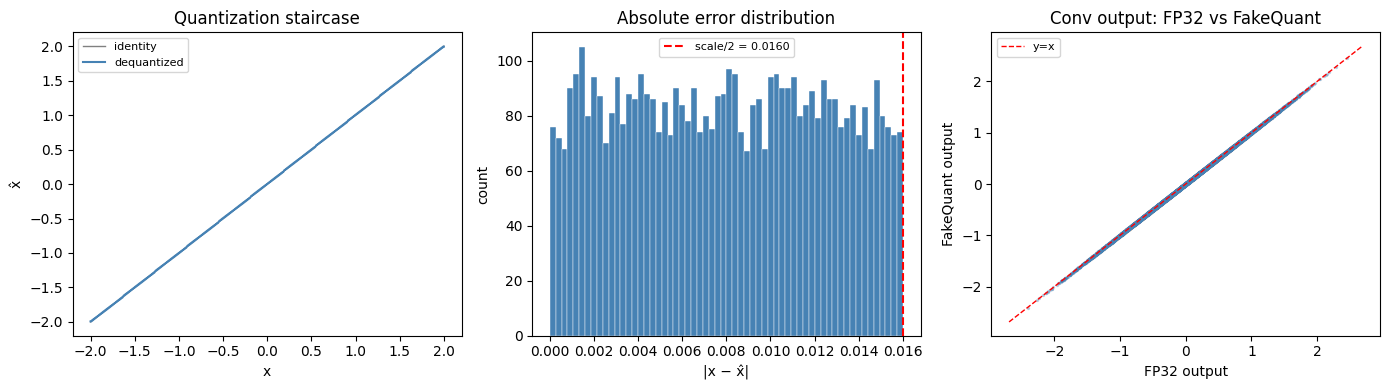

Saved → results/figures/fakequant_sanity.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- (a) input vs dequantized ---
x_vis = torch.linspace(-2, 2, 500)
scale_v, zp_v = compute_scale_zp(-2.0, 2.0)
x_vis_hat = fake_quantize(x_vis, scale_v, zp_v)

axes[0].plot(x_vis.numpy(), x_vis.numpy(), 'gray', lw=1, label='identity')
axes[0].plot(x_vis.numpy(), x_vis_hat.numpy(), 'steelblue', lw=1.5, label='dequantized')
axes[0].set_title('Quantization staircase')
axes[0].set_xlabel('x'); axes[0].set_ylabel('x̂')
axes[0].legend(fontsize=8)

# --- (b) absolute error distribution ---
x_rand = torch.randn(5000)
s, z = compute_scale_zp(float(x_rand.min()), float(x_rand.max()))
err = (x_rand - fake_quantize(x_rand, s, z)).abs().numpy()

axes[1].hist(err, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(s / 2, color='red', lw=1.5, ls='--', label=f'scale/2 = {s/2:.4f}')
axes[1].set_title('Absolute error distribution')
axes[1].set_xlabel('|x − x̂|'); axes[1].set_ylabel('count')
axes[1].legend(fontsize=8)

# --- (c) conv output scatter (FP32 vs FakeQuant) ---
axes[2].scatter(
    y_fp32.flatten().detach().numpy()[::10],
    y_fq.flatten().detach().numpy()[::10],
    s=2, alpha=0.3, color='steelblue'
)
lim = max(abs(y_fp32.min().item()), abs(y_fp32.max().item()))
axes[2].plot([-lim, lim], [-lim, lim], 'r--', lw=1, label='y=x')
axes[2].set_title('Conv output: FP32 vs FakeQuant')
axes[2].set_xlabel('FP32 output'); axes[2].set_ylabel('FakeQuant output')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/fakequant_sanity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/figures/fakequant_sanity.png")

---
## 9  Summary

| Test | Status |
|---|---|
| Scale / zero-point formula matches PyTorch | ✓ |
| Round-trip error ≤ scale/2 | ✓ |
| Out-of-range values saturate | ✓ |
| Asymmetric vs symmetric both work | ✓ |
| STE gradients are all-ones | ✓ |
| Fake-quantized conv: SNR > 20 dB, Pearson > 0.999, masked rel error < 5% | ✓ |

All tests pass → safe to implement `fake_quant.py` and `calibrate.py`.